# Ecological Value / MESLI

This notebook processes all input data directly within the notebook: transformation to `EPSG:3035`, resampling to `1000 m`, normalization to `0-1`, combination into a MESLI-raster, and final filtering to forest areas.

## Indicator Table

| Category | Ecosystem / Ecological value | Unit measure | Dataset | Use in MESLI |
|---|---|---|---|---|
| Forest area | Extent of analysis where wildfires are possible | km2 / forest yes-no | CORINE Land Cover 2018 | Final forest mask only |
| Biodiversity | Species richness / endangered species | Natura2000 habitat yes-no | Natura2000 | Binary 0/1 indicator |
| Biodiversity | Value of forest | Share of old-growth/primary; type of trees | CORINE Land Cover | Forest type proxy |
| Provisioning | Timber production | Ton per ha | BAWS Map 2020 | Provisioning category score |
| Cultural | Recreation / naturalness | Human modification 0-1 | Global Human Modification | Cultural category score, inverted |
| Regulating | Climate local regulation / biomass | Ton per ha | Biomass Map 2020 | Regulating sub-indicator |
| Regulating | Improved air quality | PM2.5 exposure | EEA air quality data 2019 | Regulating sub-indicator, inverted |

MESLI follows the following logic: every indicator is normalized to `0-1`, then the four categories `Provisioning`, `Cultural`, `Regulating`, and `Biodiversity` are equally weighted. `Forest area` is not averaged into MESLI; it is the final 0/1 mask.


## 0. Setup

In [ ]:
'''
from pathlib import Path
import sys
import copy
import base64
from io import BytesIO
import folium
from PIL import Image
from branca.colormap import LinearColormap
import shutil
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from affine import Affine
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.transform import from_origin, array_bounds
from rasterio.warp import calculate_default_transform, reproject, transform_bounds
'''

import base64
import copy
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shutil
import subprocess
import sys

from affine import Affine
from branca.colormap import LinearColormap
from io import BytesIO
from IPython.display import display
from pathlib import Path
from PIL import Image
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.transform import from_origin, array_bounds
from rasterio.warp import calculate_default_transform, reproject, transform_bounds

ROOT_DIR = Path.cwd()

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

PATH_DATA = ROOT_DIR / 'Data'
PATH_RAW = PATH_DATA / 'Raw'
PATH_PROCESSED = PATH_DATA / 'Processed'
PATH_OUTPUTS = ROOT_DIR / 'Outputs'

for p in [PATH_RAW, PATH_PROCESSED, PATH_OUTPUTS]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_CRS = CRS.from_epsg(3035)
RESOLUTION = 1000
NODATA = -9999.0

corine_path = PATH_RAW / 'U2018_CLC2018_V2020_20u1.tif'
clc_dbf_path = PATH_RAW / 'U2018_CLC2018_V2020_20u1.tif.vat.dbf'
natura_path = PATH_RAW / 'Natura2000_end2024.gpkg'
baws_path = PATH_RAW / 'BAWS_Map_2020.tif'
biomass_path = PATH_RAW / 'Biomass_Map_2020.tif'
ghm_path = PATH_RAW / 'gHM_Clipped.tif'
pm25_path = PATH_RAW / 'pm25_avg19.tif'

input_paths = [corine_path, clc_dbf_path, natura_path, baws_path, biomass_path, ghm_path, pm25_path]
pd.DataFrame({'file': [str(p) for p in input_paths], 'exists': [p.exists() for p in input_paths]})

,file,exists
0,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
1,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
2,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
3,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
4,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
5,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True
6,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True


## 1. Reading CORINE Attribute Table

The forest classes are:

- `23` = `311` Broad-leaved forest
- `24` = `312` Coniferous forest
- `25` = `313` Mixed forest

In [2]:
clc_lookup = pd.DataFrame({
    'Value': [23, 24, 25],
    'CODE_18': ['311', '312', '313'],
    'LABEL3': ['Broad-leaved forest', 'Coniferous forest', 'Mixed forest'],
    'forest_mask_value': [1, 1, 1],
    'forest_type_score': [1.00, 0.50, 0.75],
})

if clc_dbf_path.exists() and shutil.which('ogr2ogr'):
    clc_csv_path =  PATH_OUTPUTS / 'clc_attribute_table.csv'
    subprocess.run([
        'ogr2ogr', '-overwrite', '-f', 'CSV', str(clc_csv_path), str(clc_dbf_path)
    ], check=True)
    clc_attribute_table = pd.read_csv(clc_csv_path)
    clc_forest_rows = clc_attribute_table[clc_attribute_table['CODE_18'].astype(str).isin(['311', '312', '313'])]
    clc_lookup = clc_forest_rows[['Value', 'CODE_18', 'LABEL3']].copy()
    clc_lookup['forest_mask_value'] = 1
    clc_lookup['forest_type_score'] = np.select(
        [clc_lookup['CODE_18'].astype(str).eq('311'), clc_lookup['CODE_18'].astype(str).eq('312'), clc_lookup['CODE_18'].astype(str).eq('313')],
        [1.00, 0.50, 0.75],
        default=np.nan,
    )
    display(clc_forest_rows[['Value', 'CODE_18', 'LABEL3', 'Count']])
else:
    clc_attribute_table = clc_lookup.copy()
    display(clc_lookup)

forest_values = clc_lookup['Value'].astype(int).tolist()
forest_type_score_map = dict(zip(clc_lookup['Value'].astype(int), clc_lookup['forest_type_score'].astype(float)))
forest_values

,Value,CODE_18,LABEL3,Count
22,23,311,Broad-leaved forest,58678001.0
23,24,312,Coniferous forest,81743560.0
24,25,313,Mixed forest,31065342.0


[23, 24, 25]

## 2. Create a common target raster

All layers are projected onto this grid:
* CRS: `EPSG:3035`
* Resolution: `1000 m`
* Extent: CORINE extent

In [3]:
with rasterio.open(corine_path) as src:
    left, bottom, right, top = transform_bounds(src.crs, TARGET_CRS, *src.bounds, densify_pts=21)

left = np.floor(left / RESOLUTION) * RESOLUTION
bottom = np.floor(bottom / RESOLUTION) * RESOLUTION
right = np.ceil(right / RESOLUTION) * RESOLUTION
top = np.ceil(top / RESOLUTION) * RESOLUTION

width = int((right - left) / RESOLUTION)
height = int((top - bottom) / RESOLUTION)
transform = from_origin(left, top, RESOLUTION, RESOLUTION)

profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': 'float32',
    'crs': TARGET_CRS,
    'transform': transform,
    'nodata': NODATA,
    'compress': 'lzw',
    'tiled': True,
    'blockxsize': 256,
    'blockysize': 256,
    'BIGTIFF': 'IF_SAFER',
}

print(f'Template: EPSG:3035, {RESOLUTION} m, {width} x {height} pixels')

Template: EPSG:3035, 1000 m, 6500 x 4600 pixels


## 3. Transform CORINE, create a forest-mask and forest-type Score

In [4]:
corine_1000 = np.full((height, width), np.nan, dtype='float32')
with rasterio.open(corine_path) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=corine_1000,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=transform,
        dst_crs=TARGET_CRS,
        dst_nodata=np.nan,
        resampling=Resampling.mode,
    )

corine_values = np.full(corine_1000.shape, -999999, dtype='int32')
valid_corine = np.isfinite(corine_1000)
corine_values[valid_corine] = np.rint(corine_1000[valid_corine]).astype('int32')

forest_mask = np.isin(corine_values, forest_values).astype('float32')

forest_type_score = np.full(corine_1000.shape, np.nan, dtype='float32')
for clc_value, score in forest_type_score_map.items():
    forest_type_score[corine_values == clc_value] = score

forest_type_score[forest_mask == 0] = np.nan

corine_out = corine_1000.astype('float32').copy()
corine_out[~np.isfinite(corine_out)] = NODATA
with rasterio.open( PATH_PROCESSED / 'corine_1000m_epsg3035.tif', 'w', **profile) as dst:
    dst.write(corine_out, 1)

forest_mask_out = forest_mask.astype('float32').copy()
with rasterio.open( PATH_PROCESSED / 'forest_mask_1000m_epsg3035.tif', 'w', **profile) as dst:
    dst.write(forest_mask_out, 1)

forest_type_out = forest_type_score.astype('float32').copy()
forest_type_out[~np.isfinite(forest_type_out)] = NODATA
with rasterio.open( PATH_PROCESSED / 'forest_type_score_1000m_epsg3035.tif', 'w', **profile) as dst:
    dst.write(forest_type_out, 1)

print('Forest pixels:', int(np.sum(forest_mask == 1)))
print('Forest mask values:', np.unique(forest_mask))

Forest pixels: 1796945
Forest mask values: [0. 1.]


## 4. Transforming continuous Rasters

BAWS, Biomass, gHM, and PM2.5 are directly reprojected/resampled into the target grid and saved as separate GeoTIFFs.

In [5]:
continuous_inputs = {
    'baws': baws_path,
    'biomass': biomass_path,
    'ghm': ghm_path,
    'pm25': pm25_path,
}

raw_layers = {}

for layer_name, path in continuous_inputs.items():
    layer = np.full((height, width), np.nan, dtype='float32')
    with rasterio.open(path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=layer,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )

    raw_layers[layer_name] = layer
    out = layer.astype('float32').copy()
    out[~np.isfinite(out)] = NODATA
    with rasterio.open( PATH_PROCESSED / f'{layer_name}_1000m_epsg3035.tif', 'w', **profile) as dst:
        dst.write(out, 1)

pd.DataFrame({
    'layer': list(raw_layers.keys()),
    'valid_pixels': [int(np.isfinite(arr).sum()) for arr in raw_layers.values()],
})

,layer,valid_pixels
0,baws,1609442
1,biomass,1834962
2,ghm,13828223
3,pm25,5902994


## 5. Rasterize Natura2000

Natura2000 is rasterized as a 0/1 raster onto the same grid. If the file is missing, MESLI will run without this layer.

In [6]:
natura2000_binary = None

if natura_path.exists() and shutil.which('gdal_rasterize'):
    left_bound = transform.c
    top_bound = transform.f
    right_bound = left_bound + width * RESOLUTION
    bottom_bound = top_bound - height * RESOLUTION
    natura_tmp =  PATH_PROCESSED / 'natura2000_binary_tmp.tif'

    subprocess.run([
        'gdal_rasterize',
        '-l', 'NaturaSite_polygon',
        '-burn', '1',
        '-init', '0',
        '-a_nodata', str(NODATA),
        '-ot', 'Float32',
        '-of', 'GTiff',
        '-co', 'COMPRESS=LZW',
        '-te', str(left_bound), str(bottom_bound), str(right_bound), str(top_bound),
        '-ts', str(width), str(height),
        '-a_srs', 'EPSG:3035',
        str(natura_path),
        str(natura_tmp),
    ], check=True)

    with rasterio.open(natura_tmp) as src:
        natura2000_binary = src.read(1).astype('float32')

    natura2000_binary = np.where(natura2000_binary > 0, 1.0, 0.0).astype('float32')
    natura2000_binary[forest_mask == 0] = np.nan

    natura_out = natura2000_binary.copy()
    natura_out[~np.isfinite(natura_out)] = NODATA
    with rasterio.open( PATH_PROCESSED / 'natura2000_binary_1000m_epsg3035.tif', 'w', **profile) as dst:
        dst.write(natura_out, 1)

    natura_tmp.unlink(missing_ok=True)
    print('Natura2000 included:', int(np.nansum(natura2000_binary == 1)), 'forest pixels in Natura2000')
else:
    print('Natura2000 not included. File or gdal_rasterize not available.')

0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:07.
Natura2000 included: 336968 forest pixels in Natura2000


## 6. Normalizing and inverting the Indicators

All indicators are normalized to the range `0–1` within the forest mask. gHM and PM2.5 are inverted.


In [7]:
indicator_layers = {}

for layer_name in ['baws', 'biomass']:
    x = raw_layers[layer_name].astype('float32').copy()
    x[forest_mask == 0] = np.nan
    valid = np.isfinite(x)
    x_min = np.nanmin(x[valid])
    x_max = np.nanmax(x[valid])
    normalized = (x - x_min) / (x_max - x_min)
    normalized[forest_mask == 0] = np.nan
    indicator_layers[f'{layer_name}_norm'] = normalized.astype('float32')

ghm_inverted = 1 - np.clip(raw_layers['ghm'].astype('float32'), 0, 1)
ghm_inverted[forest_mask == 0] = np.nan
indicator_layers['ghm_inverted'] = ghm_inverted.astype('float32')

pm25 = raw_layers['pm25'].astype('float32').copy()
pm25[forest_mask == 0] = np.nan
pm25_valid = np.isfinite(pm25)
pm25_min = np.nanmin(pm25[pm25_valid])
pm25_max = np.nanmax(pm25[pm25_valid])
pm25_norm = (pm25 - pm25_min) / (pm25_max - pm25_min)
pm25_inverted = 1 - pm25_norm
pm25_inverted[forest_mask == 0] = np.nan
indicator_layers['pm25_inverted_norm'] = pm25_inverted.astype('float32')

indicator_layers['forest_type_score'] = forest_type_score.astype('float32')

if natura2000_binary is not None:
    indicator_layers['natura2000_binary'] = natura2000_binary.astype('float32')

for layer_name, arr in indicator_layers.items():
    out = arr.astype('float32').copy()
    out[~np.isfinite(out)] = NODATA
    with rasterio.open( PATH_PROCESSED / f'{layer_name}_1000m_epsg3035.tif', 'w', **profile) as dst:
        dst.write(out, 1)

indicator_check = pd.DataFrame({
    'indicator': list(indicator_layers.keys()),
    'valid_pixels': [int(np.isfinite(arr).sum()) for arr in indicator_layers.values()],
    'min': [float(np.nanmin(arr)) for arr in indicator_layers.values()],
    'max': [float(np.nanmax(arr)) for arr in indicator_layers.values()],
    'mean': [float(np.nanmean(arr)) for arr in indicator_layers.values()],
})
indicator_check


,indicator,valid_pixels,min,max,mean
0,baws_norm,1191306,0.000000,1.0,0.217737
1,biomass_norm,1365523,0.000000,1.0,0.213676
2,ghm_inverted,1796016,0.055722,1.0,0.703260
3,pm25_inverted_norm,1791177,0.000000,1.0,0.851246
4,forest_type_score,1796945,0.500000,1.0,0.708986
5,natura2000_binary,1796945,0.000000,1.0,0.187523


## 7. Calculating category Scores

The four categories are first established; each category carries equal weight in the final MESLI.


In [8]:
category_layers = {}

category_layers['provisioning_score'] = indicator_layers['baws_norm'].astype('float32')
category_layers['cultural_score'] = indicator_layers['ghm_inverted'].astype('float32')

regulating_stack = np.stack([
    indicator_layers['biomass_norm'],
    indicator_layers['pm25_inverted_norm'],
])
regulating_valid = np.all(np.isfinite(regulating_stack), axis=0)
regulating_score = np.full((height, width), np.nan, dtype='float32')
regulating_score[regulating_valid] = np.mean(regulating_stack[:, regulating_valid], axis=0)
regulating_score[forest_mask == 0] = np.nan
category_layers['regulating_score'] = regulating_score

biodiversity_inputs = [indicator_layers['forest_type_score']]
if 'natura2000_binary' in indicator_layers:
    biodiversity_inputs.append(indicator_layers['natura2000_binary'])

biodiversity_stack = np.stack(biodiversity_inputs)
biodiversity_valid = np.all(np.isfinite(biodiversity_stack), axis=0)
biodiversity_score = np.full((height, width), np.nan, dtype='float32')
biodiversity_score[biodiversity_valid] = np.mean(biodiversity_stack[:, biodiversity_valid], axis=0)
biodiversity_score[forest_mask == 0] = np.nan
category_layers['biodiversity_score'] = biodiversity_score

for layer_name, arr in category_layers.items():
    out = arr.astype('float32').copy()
    out[~np.isfinite(out)] = NODATA
    with rasterio.open( PATH_PROCESSED / f'{layer_name}_1000m_epsg3035.tif', 'w', **profile) as dst:
        dst.write(out, 1)

category_check = pd.DataFrame({
    'category_score': list(category_layers.keys()),
    'valid_pixels': [int(np.isfinite(arr).sum()) for arr in category_layers.values()],
    'min': [float(np.nanmin(arr)) for arr in category_layers.values()],
    'max': [float(np.nanmax(arr)) for arr in category_layers.values()],
    'mean': [float(np.nanmean(arr)) for arr in category_layers.values()],
})
category_check


,category_score,valid_pixels,min,max,mean
0,provisioning_score,1191306,0.000000,1.000000,0.217737
1,cultural_score,1796016,0.055722,1.000000,0.703260
2,regulating_score,1364583,0.083284,0.950943,0.538509
3,biodiversity_score,1796945,0.250000,1.000000,0.448254


## 8. Calculate MESLI, apply the final mask, and normalize to 0–1 again

`MESLI_raw` is the equally weighted average of the four category scores. Theoretically, this value already lies between `0` and `1`, but it does not necessarily utilize the entire range of values. For later combination with a vulnerability-axis, `MESLI_normalized` is additionally normalized to `0-1` within the forest-mask.


In [9]:
category_stack = np.stack([
    category_layers['provisioning_score'],
    category_layers['cultural_score'],
    category_layers['regulating_score'],
    category_layers['biodiversity_score'],
])
valid_mesli = np.all(np.isfinite(category_stack), axis=0)

mesli_raw = np.full((height, width), np.nan, dtype='float32')
mesli_raw[valid_mesli] = np.mean(category_stack[:, valid_mesli], axis=0)
mesli_raw[forest_mask == 0] = np.nan

mesli_raw_out = mesli_raw.astype('float32').copy()
mesli_raw_out[~np.isfinite(mesli_raw_out)] = NODATA
with rasterio.open( PATH_OUTPUTS / 'MESLI_ecological_value_raw_1000m_epsg3035.tif', 'w', **profile) as dst:
    dst.write(mesli_raw_out, 1)

mesli_valid = np.isfinite(mesli_raw) & (forest_mask == 1)
mesli_min = np.nanmin(mesli_raw[mesli_valid])
mesli_max = np.nanmax(mesli_raw[mesli_valid])
mesli = np.full((height, width), np.nan, dtype='float32')
mesli[mesli_valid] = (mesli_raw[mesli_valid] - mesli_min) / (mesli_max - mesli_min)
mesli[forest_mask == 0] = np.nan

mesli_out = mesli.astype('float32').copy()
mesli_out[~np.isfinite(mesli_out)] = NODATA
with rasterio.open( PATH_OUTPUTS / 'MESLI_ecological_value_1000m_epsg3035.tif', 'w', **profile) as dst:
    dst.write(mesli_out, 1)

summary_rows = []
for layer_name, arr in {**indicator_layers, **category_layers, 'MESLI_raw': mesli_raw, 'MESLI_normalized': mesli}.items():
    values = arr[np.isfinite(arr)]
    summary_rows.append({
        'layer': layer_name,
        'valid_pixels': int(values.size),
        'min': float(values.min()) if values.size else np.nan,
        'max': float(values.max()) if values.size else np.nan,
        'mean': float(values.mean()) if values.size else np.nan,
    })

indicator_summary = pd.DataFrame(summary_rows)
indicator_summary.to_csv( PATH_OUTPUTS / 'indicator_summary.csv', index=False)
print(f'Raw MESLI range before final normalization: {mesli_min:.3f} to {mesli_max:.3f}')
indicator_summary


Raw MESLI range before final normalization: 0.217 to 0.903


,layer,valid_pixels,min,max,mean
0,baws_norm,1191306,0.000000,1.000000,0.217737
1,biomass_norm,1365523,0.000000,1.000000,0.213676
2,ghm_inverted,1796016,0.055722,1.000000,0.703260
3,pm25_inverted_norm,1791177,0.000000,1.000000,0.851246
4,forest_type_score,1796945,0.500000,1.000000,0.708986
5,natura2000_binary,1796945,0.000000,1.000000,0.187523
6,provisioning_score,1191306,0.000000,1.000000,0.217737
7,cultural_score,1796016,0.055722,1.000000,0.703260
8,regulating_score,1364583,0.083284,0.950943,0.538509
9,biodiversity_score,1796945,0.250000,1.000000,0.448254


## 9. Validation

In [10]:
folders_to_check = [PATH_OUTPUTS, PATH_PROCESSED]

validation_rows = []

for folder in folders_to_check:
    for path in sorted(folder.glob('*.tif')):
        with rasterio.open(path) as src:
            validation_rows.append({
                'file': path.name,
                'crs': src.crs.to_string(),
                'pixel_width': src.transform.a,
                'pixel_height': abs(src.transform.e),
                'width': src.width,
                'height': src.height,
                'same_grid': src.crs == TARGET_CRS and src.transform == transform and src.width == width and src.height == height,
            })

validation = pd.DataFrame(validation_rows)
validation.to_csv( PATH_OUTPUTS / 'output_grid_validation.csv', index=False)

print('Forest mask unique values:', np.unique(forest_mask))
print('MESLI min/max:', float(np.nanmin(mesli)), float(np.nanmax(mesli)))
print('All output grids aligned:', bool(validation['same_grid'].all()))
validation

Forest mask unique values: [0. 1.]
MESLI min/max: 0.0 1.0
All output grids aligned: True


,file,crs,pixel_width,pixel_height,width,height,same_grid
0,MESLI_ecological_value_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
1,MESLI_ecological_value_raw_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
2,baws_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
3,baws_norm_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
4,biodiversity_score_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
5,biomass_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
6,biomass_norm_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
7,corine_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
8,cultural_score_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True
9,forest_mask_1000m_epsg3035.tif,EPSG:3035,1000.0,1000.0,6500,4600,True


## 10. Static Preview

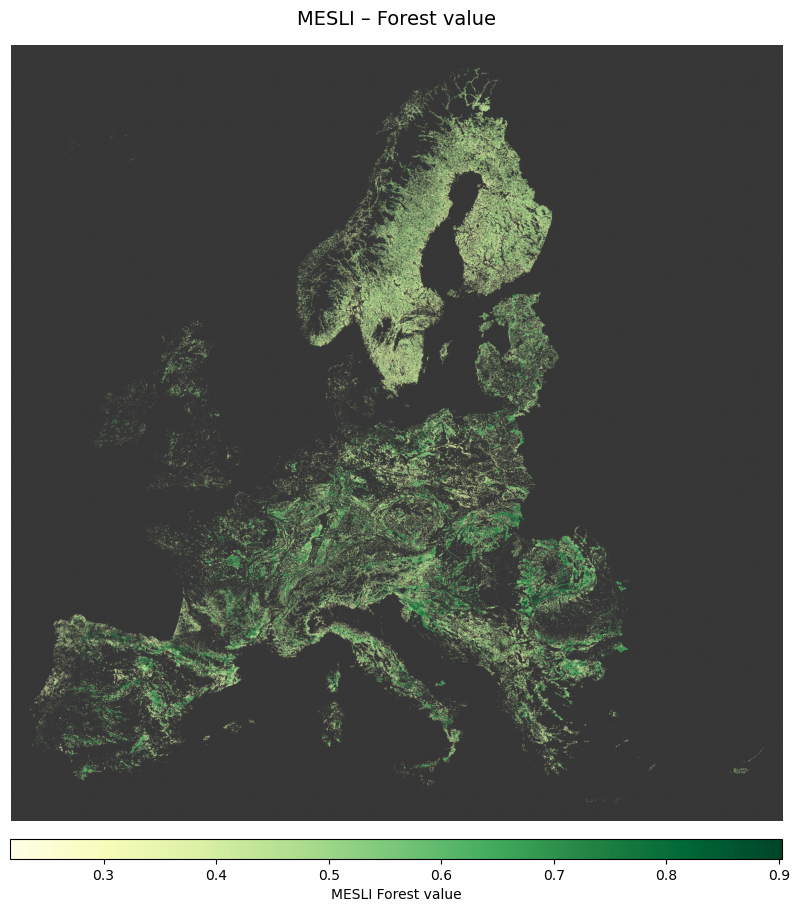

In [ ]:
mesli_cmap = copy.copy(plt.get_cmap("YlGn"))
mesli_cmap.set_bad(color="#373737FF")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(mesli_raw, cmap=mesli_cmap)

cbar = fig.colorbar(
    im, 
    ax=ax, 
    label='MESLI Forest value', 
    orientation='horizontal',
    shrink=0.66, 
    aspect=40, 
    pad=0.02
)

ax.set_title('MESLI – Forest value', fontsize=14, pad=15)
ax.axis('off')

fig.tight_layout()

valid_pixels = np.argwhere(~np.isnan(mesli_raw))

if len(valid_pixels) > 0:
    ymin, xmin = valid_pixels.min(axis=0)
    ymax, xmax = valid_pixels.max(axis=0)
    
    buffer = 100
    
    ax.set_xlim(xmin - buffer, xmax + buffer)
    ax.set_ylim(ymax + buffer, ymin - buffer)
    
fig.savefig( PATH_OUTPUTS / 'MESLI_static_preview.png', dpi=300, bbox_inches='tight')
plt.show(block=False)

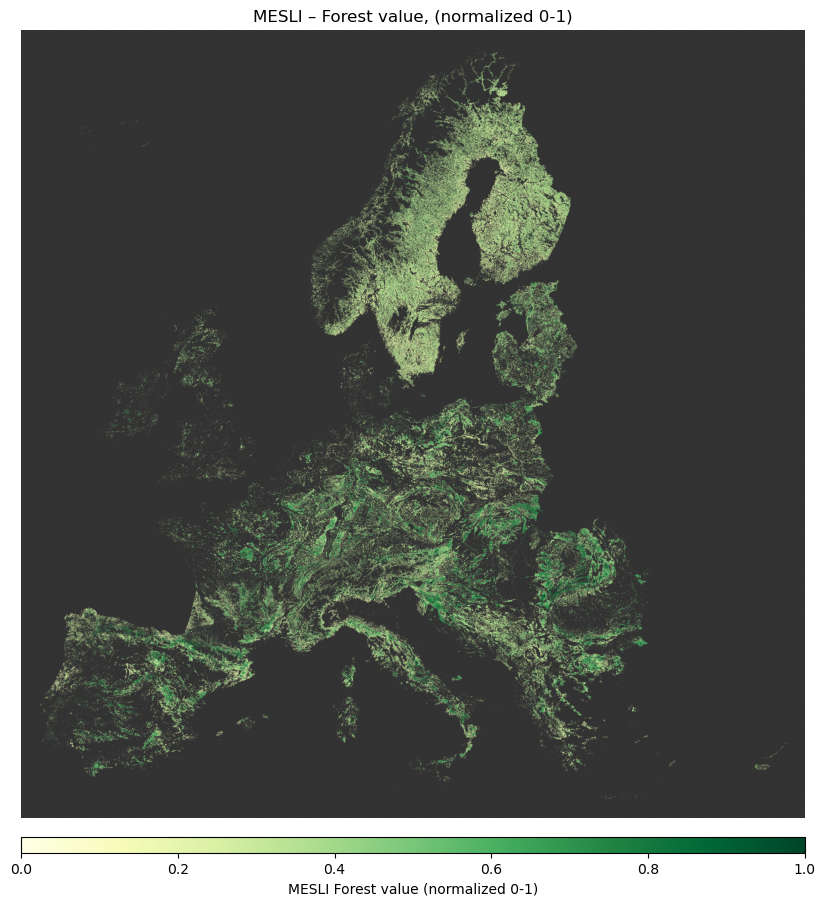

In [ ]:
mesli_cmap = copy.copy(plt.get_cmap("YlGn"))
mesli_cmap.set_bad(color="#333333FF")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(mesli, cmap=mesli_cmap, vmin=0, vmax=1)
cbar = fig.colorbar(
    im, 
    ax=ax, 
    label='MESLI Forest value (normalized 0-1)', 
    orientation='horizontal',
    shrink=0.67, 
    aspect=50, 
    pad=0.02
)
ax.set_title('MESLI – Forest value, (normalized 0-1)')
ax.axis('off')
fig.tight_layout()

if len(valid_pixels) > 0:
    ymin, xmin = valid_pixels.min(axis=0)
    ymax, xmax = valid_pixels.max(axis=0)
   
    buffer = 100
   
    ax.set_xlim(xmin - buffer, xmax + buffer)
    ax.set_ylim(ymax + buffer, ymin - buffer)

fig.savefig( PATH_OUTPUTS / 'MESLI_static_preview_rescaled.png', dpi=300)
plt.show(block=False)

## 11. Interactive Folium Map

The grid is set to `EPSG:3857` for Leaflet/Folium, so that it matches the basemap.

Saved interactive map to /Users/maxlengenfelder/Desktop/FS26/GEO888/GEO888_Wildfire_Indicator/Outputs/MESLI_interactive_map.html



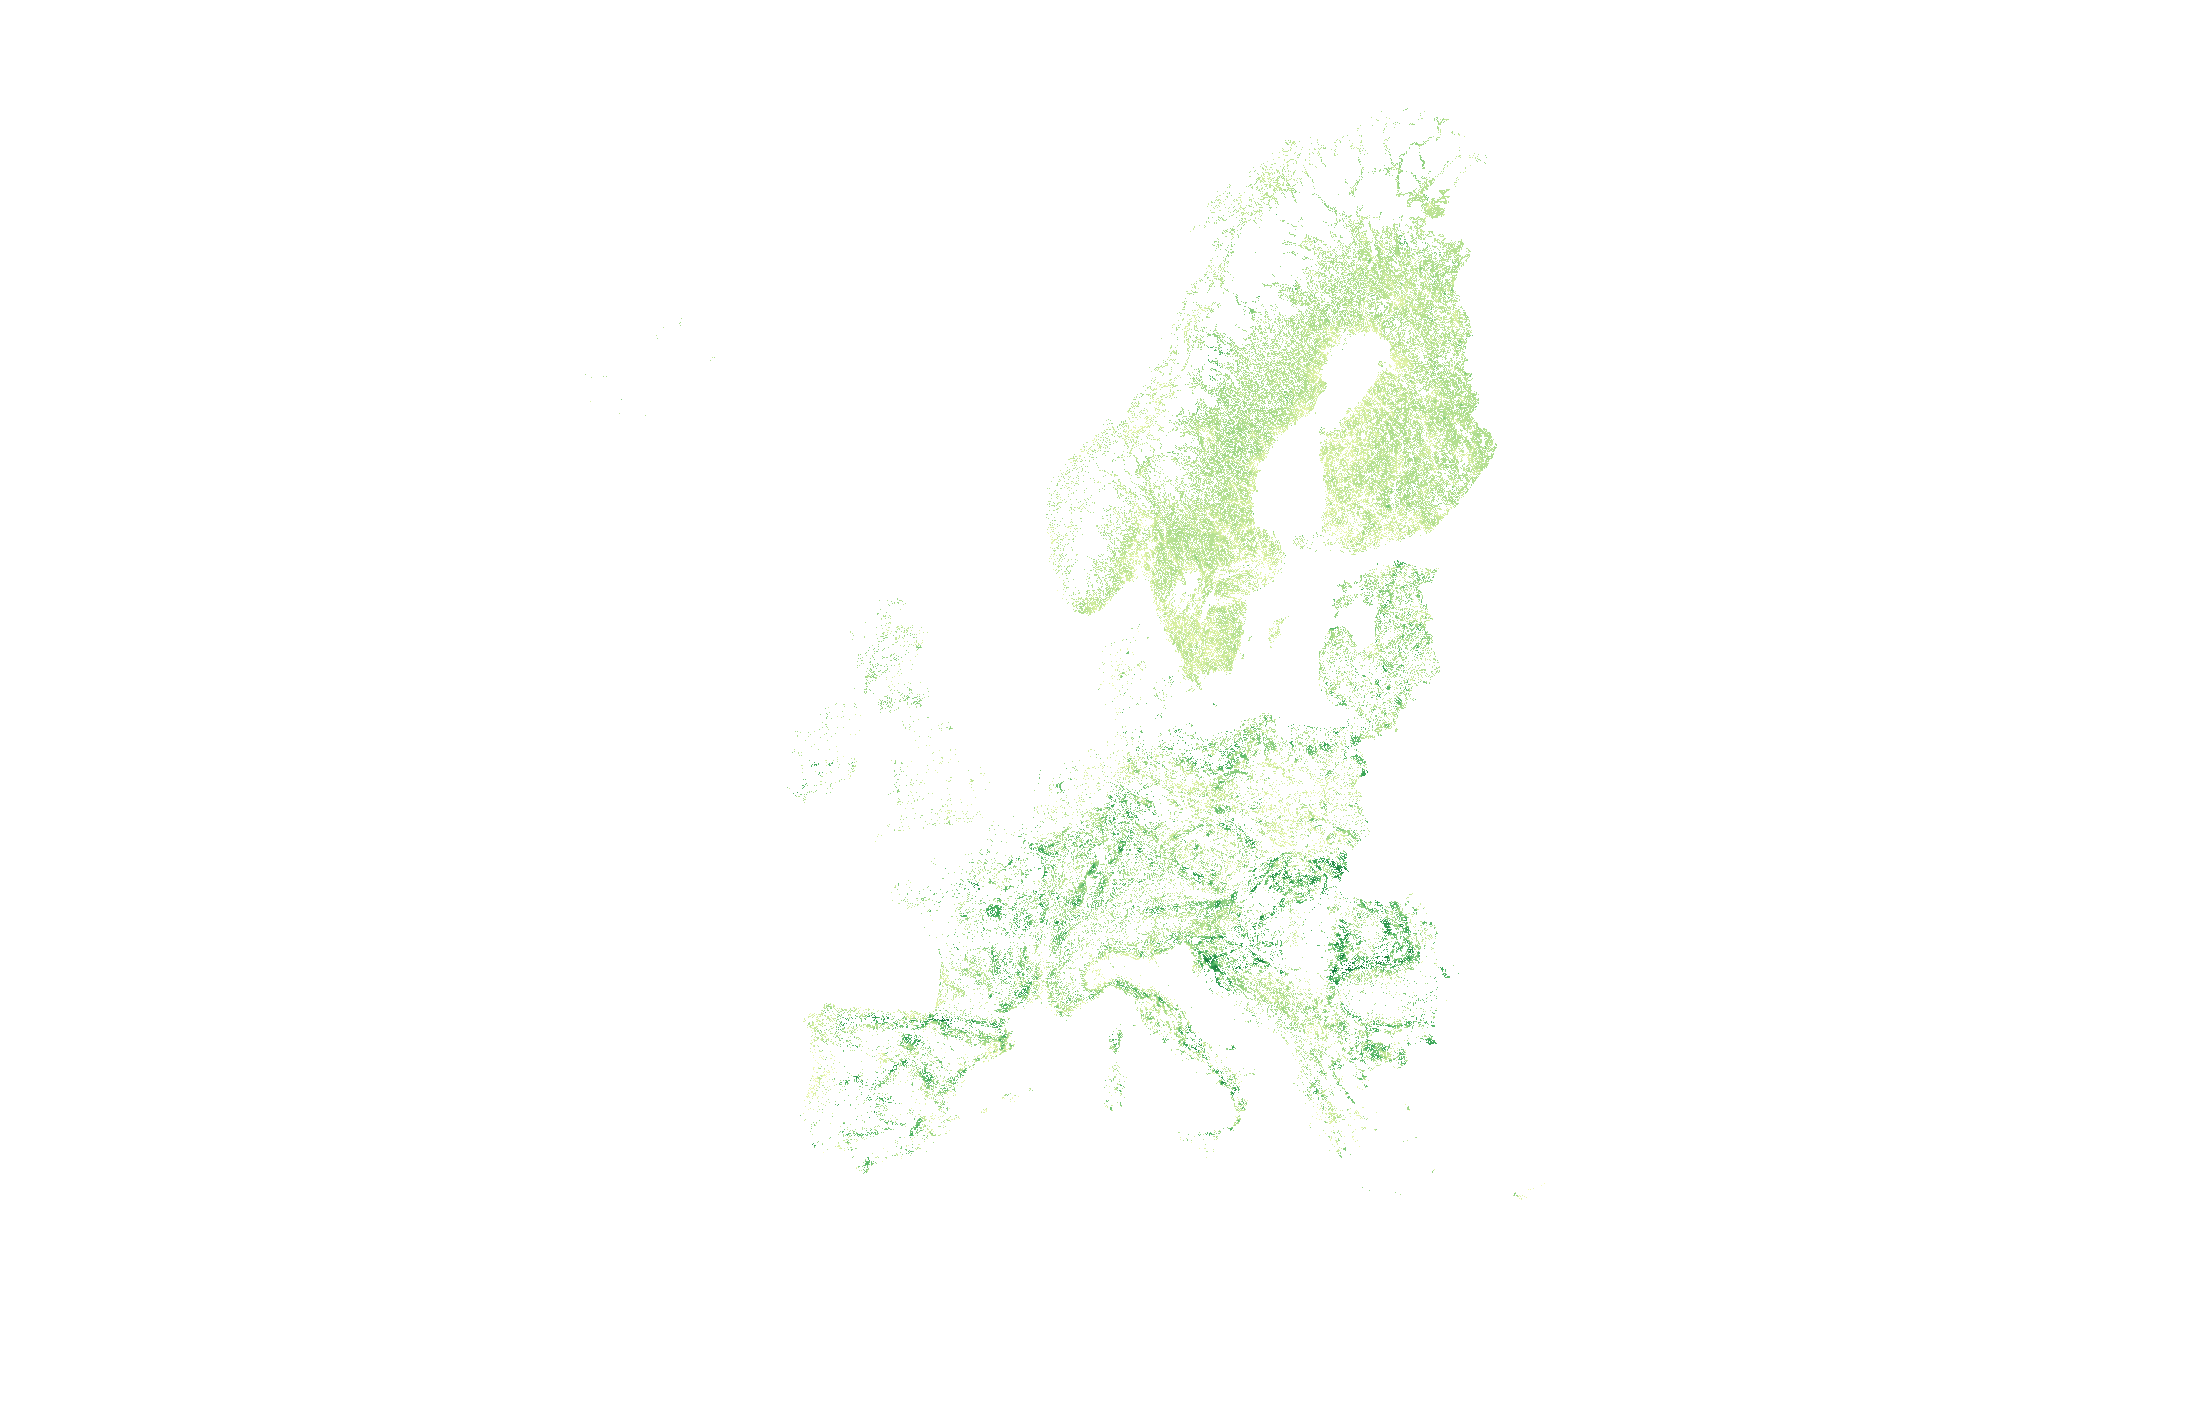

In [ ]:
mesli_path =  PATH_OUTPUTS / 'MESLI_ecological_value_1000m_epsg3035.tif'
html_path =  PATH_OUTPUTS / 'MESLI_interactive_map.html'

max_dimension = 2200
leaflet_crs = 'EPSG:3857'

with rasterio.open(mesli_path) as src:
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, leaflet_crs, src.width, src.height, *src.bounds
    )

    scale = max(dst_width, dst_height) / max_dimension
    if scale > 1:
        new_width = int(dst_width / scale)
        new_height = int(dst_height / scale)
        dst_transform = dst_transform * Affine.scale(dst_width / new_width, dst_height / new_height)
        dst_width, dst_height = new_width, new_height

    mesli_webmercator = np.full((dst_height, dst_width), np.nan, dtype='float32')
    reproject(
        source=rasterio.band(src, 1),
        destination=mesli_webmercator,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=dst_transform,
        dst_crs=leaflet_crs,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )

west_m, south_m, east_m, north_m = array_bounds(dst_height, dst_width, dst_transform)
west, south, east, north = transform_bounds(leaflet_crs, 'EPSG:4326', west_m, south_m, east_m, north_m, densify_pts=21)

mask = np.isfinite(mesli_webmercator)
cmap = plt.get_cmap('YlGn')
rgba = np.zeros((dst_height, dst_width, 4), dtype=np.uint8)
rgba[mask] = (cmap(np.clip(mesli_webmercator[mask], 0, 1)) * 255).astype(np.uint8)
rgba[~mask] = [0, 0, 0, 0]

png = BytesIO()
Image.fromarray(rgba).save(png, format='PNG')
image_url = 'data:image/png;base64,' + base64.b64encode(png.getvalue()).decode('ascii')

m = folium.Map(location=[(south + north) / 2, (west + east) / 2], zoom_start=4, tiles='cartodb darkmatter')
folium.raster_layers.ImageOverlay(
    image=image_url,
    bounds=[[south, west], [north, east]],
    opacity=0.8,
    name='MESLI ecological value, normalized 0-1',
    interactive=True,
).add_to(m)

colormap = LinearColormap(
    colors=["#ffcb6b", "#fbf4aa", '#78c679', "#198e3c", "#013F22"],
    vmin=0,
    vmax=1,
)
colormap.caption = 'MESLI ecological value, normalized 0-1'
colormap.add_to(m)

folium.LayerControl().add_to(m)

m.fit_bounds([[south, west], [north, east]])
m.save(html_path)
print(f'Saved interactive map to {html_path}')
m